In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("/content/diabetes.csv")

print(df.head())
print("Dataset shape:", df.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Dataset shape: (768, 9)


In [ ]:
# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
# Replace invalid 0 values with NaN
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[cols] = X[cols].replace(0, np.nan)

# Missing value handling
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

In [ ]:
# Train model
dt_model.fit(X_train, y_train)

# Prediction
y_pred = dt_model.predict(X_test)

In [ ]:


# Evaluation
print("\n===== PERFORMANCE =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




===== PERFORMANCE =====
Accuracy : 0.7857
Precision: 0.6981
Recall   : 0.6852
F1 Score : 0.6916

Confusion Matrix:
[[84 16]
 [17 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



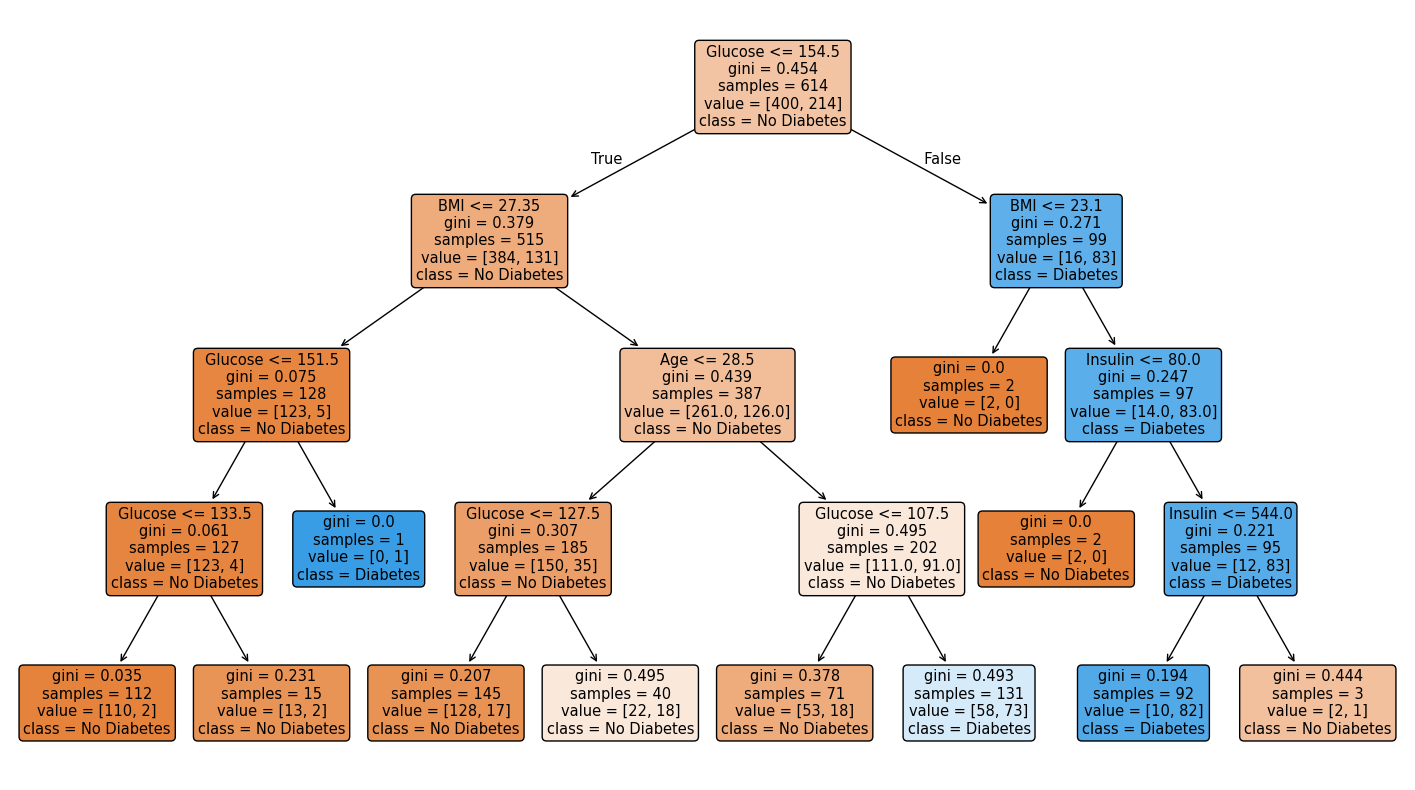

In [ ]:
# Visualize Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True
)
plt.show()